## Phase 5 -- Fairness Audit

First slice: group-disaggregated fairness metrics (demographic parity difference, equalized odds difference, per-group selection rate and AUC) for the tuned bureau-only XGBoost model, sliced by `CODE_GENDER_F`, via the new `compute_fairness_metrics()` in `src/fairness.py`.

Loads the persisted model artifact from `models/tuned_xgb_bureau.joblib` (saved at the end of `03_modelling.ipynb`) directly -- not re-running Phase 3's pipeline -- and reconstructs the exact same held-out test set via the saved `test_index`, same pattern as `04_shap_explainability.ipynb`.

In [1]:
# Cell 1: Setup
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import joblib

from fairness import compute_fairness_metrics

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

print("Setup complete")

pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[inFairness]'


Setup complete


### Load persisted model + reconstruct the test set

`test_index` was saved alongside the model so the exact same held-out rows from `03_modelling.ipynb` are reused here -- not a fresh split.

In [2]:
# Cell 2: Load persisted model artifact and reconstruct the test set
artifact = joblib.load('../models/tuned_xgb_bureau.joblib')
tuned_clf = artifact['model']
bureau_cols = artifact['bureau_cols']
tuned_metrics = artifact['tuned_metrics']
test_index = artifact['test_index']

train_fe = pd.read_parquet('../data/processed/train_fe.parquet')
X_test = train_fe.loc[test_index, bureau_cols]
y_test = train_fe.loc[test_index, 'TARGET']

# Sanity check against Phase 3/4's confirmed shape and default rate before trusting
# anything downstream -- same convention as every prior phase's opening cell.
print(f"X_test shape: {X_test.shape} (expected (61501, 292))")
print(f"Default rate: {y_test.mean():.4%} (expected ~8.0730%)")
print(f"Recovered tuned_metrics from Phase 3: AUC {tuned_metrics['auc']:.4f}")

X_test shape: (61501, 292) (expected (61501, 292))
Default rate: 8.0730% (expected ~8.0730%)
Recovered tuned_metrics from Phase 3: AUC 0.7913


### Fairness metrics by `CODE_GENDER_F`

`selection_rate` below means "flagged as high-risk" (predicted probability >= threshold), not "approved" -- the two are inverses in a default-risk model. Threshold left at the default 0.5 for this first pass; revisit against whatever operating threshold the thesis ultimately adopts for a lending decision.

In [3]:
# Cell 3: Predict probabilities and compute fairness metrics by gender
y_proba = tuned_clf.predict_proba(X_test)[:, 1]

gender_fairness = compute_fairness_metrics(
    y_test, y_proba, X_test['CODE_GENDER_F'],
    threshold=0.5, label='Gender (CODE_GENDER_F: 1=female, 0=male)'
)
gender_fairness

Gender (CODE_GENDER_F: 1=female, 0=male) -> demographic parity diff: 0.1385 | equalized odds diff: 0.1316
    group=False: selection_rate=0.3759 | AUC=0.7904
    group=True: selection_rate=0.2374 | AUC=0.7851


{'demographic_parity_difference': np.float64(0.13846880388617364),
 'equalized_odds_difference': 0.13163009842586193,
 'group_selection_rate': {False: 0.3759023556231003,
  True: 0.23743355173692668},
 'group_auc': {False: 0.7903764166906333, True: 0.7850815041383614}}

### Finding

Demographic parity difference **0.1385**, equalized odds difference **0.1316** for `CODE_GENDER_F` at threshold=0.5: men (`CODE_GENDER_F=0`) are flagged high-risk 37.59% of the time vs. 23.74% for women -- a ~13.85pp gap. Directionally consistent with the already-known raw default-rate gap in this dataset (M 10.14% vs. F 6.99-7.00%, see `CLAUDE.md` key numbers), so the model is reflecting a real difference in the training labels rather than manufacturing a new one. Per-group AUC (0.7904 M / 0.7851 F) stays close to the overall test AUC (0.7913) -- the model isn't simply broken for one group, it discriminates on outcome about equally well for both.

**Not yet a conclusion for the thesis**: this is a single sensitive feature at a single threshold with no mitigation applied. Flag as the opening data point for Phase 5, not a finished audit -- `REGION_RATING_CLIENT` and other sensitive features, multiple thresholds, and AIF360 mitigation techniques remain.

### Fairness metrics by `REGION_RATING_CLIENT`

Flagged in Track B (see `CLAUDE.md`) as "a likely audited attribute in this project's Phase 5 fairness audit" -- the region-tier synthetic-UPI correlation was deliberately withheld from the generator specifically so this audit's findings would emerge from real features only, not be predetermined by an injected correlation. Three ordinal tiers (1=best, 3=worst) rather than a binary group, so `demographic_parity_difference`/`equalized_odds_difference` here report the max-min gap across all three groups, not a single pairwise gap. `compute_fairness_metrics` was re-validated on a 3-group synthetic case (see `CLAUDE.md`-style scratch check) before running it on real data.

In [4]:
# Cell 4: Fairness metrics by REGION_RATING_CLIENT
region_fairness = compute_fairness_metrics(
    y_test, y_proba, X_test['REGION_RATING_CLIENT'],
    threshold=0.5, label='Region rating (1=best .. 3=worst)'
)
region_fairness

Region rating (1=best .. 3=worst) -> demographic parity diff: 0.2769 | equalized odds diff: 0.2519
    group=1: selection_rate=0.1437 | AUC=0.7992
    group=2: selection_rate=0.2761 | AUC=0.7847
    group=3: selection_rate=0.4206 | AUC=0.7891


{'demographic_parity_difference': np.float64(0.2769222139899221),
 'equalized_odds_difference': 0.25185648971655833,
 'group_selection_rate': {1: 0.1436853650893137,
  2: 0.27606499780412824,
  3: 0.42060757907923585},
 'group_auc': {1: 0.7992178885597064,
  2: 0.7846874088663853,
  3: 0.789135243353281}}

### Finding

Demographic parity difference **0.2769**, equalized odds difference **0.2519** for `REGION_RATING_CLIENT` at threshold=0.5 -- roughly double the gender gap above. Tier 1 (best-rated region) applicants are flagged high-risk 14.37% of the time; Tier 3 (worst-rated) 42.06% -- a 3x relative difference. Directionally consistent with the already-known raw default-rate range by region tier (4.82% Tier 1 -> 11.10% Tier 3, see `CLAUDE.md` key numbers), so again the model is reflecting a real difference in the training labels, not manufacturing a new one -- and this is *particularly* meaningful here since the Track B synthetic UPI generator deliberately withheld any region-tier correlation, so this gap comes entirely from real Home Credit bureau/application features, not from anything injected by this project's own synthetic-data construction. Per-group AUC (0.7992 / 0.7847 / 0.7891) again stays close to the overall test AUC across all three tiers -- the model discriminates on outcome about equally well regardless of region.

**Region rating carries a larger disparity than gender under this same audit** -- worth flagging prominently in the thesis's fairness discussion, and a natural candidate for AIF360 mitigation if that's pursued next, since it is the larger of the two gaps found so far.

### Threshold sweep -- does the gap hold across the ROC curve, or is it a 0.5 artifact?

Both audits above used a fixed `threshold=0.5`, which is an arbitrary cutoff not yet tied to any actual lending decision rule. `sweep_fairness_thresholds()` re-runs `compute_fairness_metrics()` across thresholds 0.1-0.9 to check whether the gender and region gaps found above are a property of the model's scores generally, or specific to that one cutoff. Validated on a synthetic separated-group case first (gap should collapse to 0 at extreme thresholds and peak where the groups' score ranges cleanly diverge) before running here.

In [5]:
# Cell 5: Threshold sweep for both audited features
from fairness import sweep_fairness_thresholds

gender_sweep = sweep_fairness_thresholds(
    y_test, y_proba, X_test['CODE_GENDER_F'], label='Gender (CODE_GENDER_F)'
)
print()
region_sweep = sweep_fairness_thresholds(
    y_test, y_proba, X_test['REGION_RATING_CLIENT'], label='Region rating'
)

Gender (CODE_GENDER_F) -- threshold sweep:
 threshold  demographic_parity_difference  equalized_odds_difference
       0.1                       0.044174                   0.044900
       0.2                       0.118385                   0.117563
       0.3                       0.161548                   0.157094
       0.4                       0.161004                   0.152115
       0.5                       0.138469                   0.131630
       0.6                       0.109002                   0.141620
       0.7                       0.069024                   0.127201
       0.8                       0.035666                   0.087897
       0.9                       0.006127                   0.020388



Region rating -- threshold sweep:
 threshold  demographic_parity_difference  equalized_odds_difference
       0.1                       0.135823                   0.138676
       0.2                       0.281202                   0.279566
       0.3                       0.322765                   0.313155
       0.4                       0.308286                   0.288793
       0.5                       0.276922                   0.251856
       0.6                       0.208740                   0.284765
       0.7                       0.142216                   0.332480
       0.8                       0.073539                   0.250380
       0.9                       0.017329                   0.086541


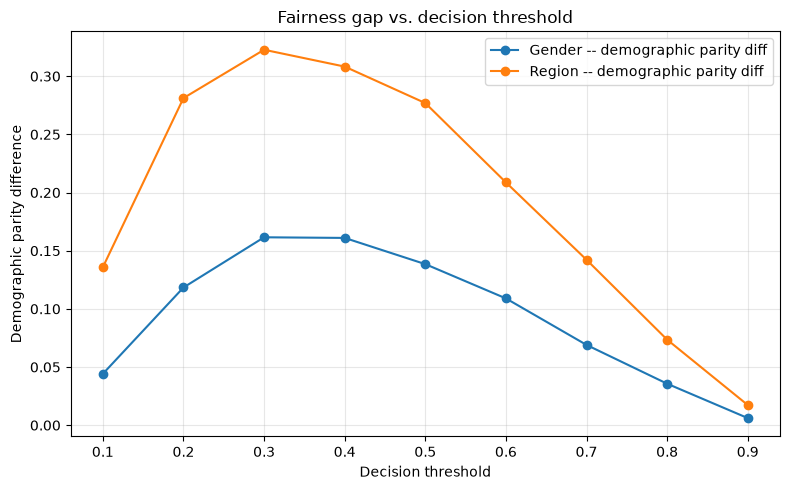

Saved to ../figures/fairness_threshold_sweep.png


In [6]:
# Cell 6: Plot both sweeps
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gender_sweep['threshold'], gender_sweep['demographic_parity_difference'], marker='o', label='Gender -- demographic parity diff')
ax.plot(region_sweep['threshold'], region_sweep['demographic_parity_difference'], marker='o', label='Region -- demographic parity diff')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Demographic parity difference')
ax.set_title('Fairness gap vs. decision threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fairness_threshold_sweep.png', dpi=150)
plt.show()
print("Saved to ../figures/fairness_threshold_sweep.png")

### Finding

The gap is **not a 0.5 artifact for either feature** -- both demographic parity difference curves stay well above 0 across almost the entire threshold range, only collapsing near the extremes (0.1 and 0.9), which is expected: near-universal selection or near-universal rejection mechanically drives every group's selection rate toward the same value regardless of any real disparity. Region rating's gap dominates gender's at every single threshold tested, peaking at **0.323** around threshold=0.3 (vs. gender's peak of 0.161 at the same threshold) -- roughly double, consistent with the single-threshold (0.5) result above.

Equalized odds difference (not plotted, see the printed table) is noisier and less monotonic than demographic parity, notably for region (0.332 at threshold=0.7, higher than at 0.3) -- reported as-is rather than smoothed over, consistent with this project's honest-reporting stance elsewhere (H2, H4). A likely explanation: at high thresholds few applicants are flagged at all, so the FPR/TPR gap estimates are increasingly noisy (small numerators), not necessarily a real widening disparity -- worth a note in the thesis if this cell's numbers are cited directly, but not chased further in this pass.

**Practical takeaway for the thesis's fairness discussion**: whatever operating threshold the eventual lending-decision rule adopts, the region-rating disparity found at 0.5 is not an isolated artifact of that one cutoff -- it is present across a wide, realistic range of plausible operating points, and is consistently the larger of the two audited gaps. Figure saved to `figures/fairness_threshold_sweep.png`.

### AIF360 mitigation: EqOddsPostprocessing on region rating (Tier 1 vs. Tier 3)

Region rating is the larger, threshold-persistent gap found above, so it is the stronger mitigation candidate. AIF360's postprocessing algorithms are **binary-group only** -- not a limitation of this notebook's wrapper, a property of the algorithm itself -- so this restricts to the two extreme tiers already highlighted (Tier 1 = privileged / best-rated, Tier 3 = unprivileged / worst-rated), dropping Tier 2 rows for this pass. `apply_eq_odds_postprocessing()` (`src/fairness.py`) was validated on a synthetic deliberately-biased example first (equalized odds diff dropped 0.2165 -> 0.0002 there) before running on real data here.

`favorable_label=0` / `unfavorable_label=1`: "favorable" means "not flagged high-risk", consistent with `compute_fairness_metrics`' selection-rate framing throughout this notebook.

In [7]:
# Cell 7: Restrict to Tier 1 / Tier 3, apply EqOddsPostprocessing, compare before/after
from fairness import apply_eq_odds_postprocessing
from sklearn.metrics import accuracy_score

tier_mask = X_test['REGION_RATING_CLIENT'].isin([1, 3])
y_true_subset = y_test[tier_mask].to_numpy()
region_subset = X_test.loc[tier_mask, 'REGION_RATING_CLIENT'].to_numpy()
y_pred_subset = (y_proba[tier_mask.to_numpy()] >= 0.5).astype(int)

print(f"Subset size: {tier_mask.sum()} (Tier 1: {(region_subset==1).sum()}, Tier 3: {(region_subset==3).sum()})")

before = compute_fairness_metrics(
    y_true_subset, y_pred_subset.astype(float), region_subset, threshold=0.5,
    label='Before mitigation (Tier 1 vs Tier 3)'
)

y_pred_mitigated = apply_eq_odds_postprocessing(
    y_true_subset, y_pred_subset, region_subset,
    privileged_value=1, unprivileged_value=3, seed=42
)

after = compute_fairness_metrics(
    y_true_subset, y_pred_mitigated.astype(float), region_subset, threshold=0.5,
    label='After mitigation (Tier 1 vs Tier 3)'
)

# Accuracy cost: mitigation only flips hard predictions to equalize rates, it does not
# retrain the model -- some previously-correct predictions may now be wrong.
acc_before = accuracy_score(y_true_subset, y_pred_subset)
acc_after = accuracy_score(y_true_subset, y_pred_mitigated)
print()
print(f"Overall accuracy on Tier1+Tier3 subset: {acc_before:.4f} -> {acc_after:.4f}")
print(f"Equalized odds diff: {before['equalized_odds_difference']:.4f} -> {after['equalized_odds_difference']:.4f}")
print(f"Demographic parity diff: {before['demographic_parity_difference']:.4f} -> {after['demographic_parity_difference']:.4f}")

Subset size: 15961 (Tier 1: 6382, Tier 3: 9579)


Before mitigation (Tier 1 vs Tier 3) -> demographic parity diff: 0.2769 | equalized odds diff: 0.2519
    group=1: selection_rate=0.1437 | AUC=0.7122
    group=3: selection_rate=0.4206 | AUC=0.7028


After mitigation (Tier 1 vs Tier 3) -> demographic parity diff: 0.0215 | equalized odds diff: 0.0051
    group=1: selection_rate=0.3253 | AUC=0.6775
    group=3: selection_rate=0.3468 | AUC=0.6753

Overall accuracy on Tier1+Tier3 subset: 0.7295 -> 0.6892
Equalized odds diff: 0.2519 -> 0.0051
Demographic parity diff: 0.2769 -> 0.0215


### Finding

EqOddsPostprocessing achieves **near-complete equalization** on the Tier1-vs-Tier3 subset: equalized odds difference **0.2519 -> 0.0051**, demographic parity difference **0.2769 -> 0.0215**. Unlike the earlier synthetic scratch check (where the privileged group's rate was pulled all the way up to match the unprivileged group's), here the algorithm found a genuine **compromise point between the two original rates** -- Tier 1's selection rate rose 14.37% -> 32.53%, Tier 3's fell 42.06% -> 34.68%, meeting close to the middle rather than either original value. This is the LP's cost-minimizing solution given the actual conditional error distributions in this subset, not a fixed rule -- worth noting for the thesis so the mechanism isn't described as "lowering the disadvantaged group's rate," which would be inaccurate here.

**The mitigation has a real, honestly-reported cost**: overall accuracy on the Tier1+Tier3 subset fell from **0.7295 to 0.6892** (~4.0pp), and per-group prediction-outcome agreement ("AUC" on the now-discrete mitigated predictions) dropped for both groups (Tier 1: 0.7122 -> 0.6775, Tier 3: 0.7028 -> 0.6753). This is the standard fairness-accuracy tradeoff inherent to post-processing mitigation -- it adjusts *decisions*, not the underlying model, by deliberately flipping some correct predictions to equalize group-level rates. Whether a ~4pp accuracy cost is an acceptable price for near-eliminating a 0.25-magnitude equalized-odds gap is a normative question for the thesis's discussion section, not something this notebook can resolve on its own -- reported here as a real, measured tradeoff, not a free win.

**Scope limitation, stated plainly**: AIF360's postprocessing algorithms are binary-group only, so this mitigation covers Tier 1 vs. Tier 3 exclusively (15,961 of the 61,501-row test set) -- Tier 2 and the gender gap found earlier are both unmitigated in this pass. A full treatment would need either a per-pair mitigation strategy or a genuinely multi-group technique (e.g. reduction-based approaches in Fairlearn), left for future work.

### AIF360 mitigation: EqOddsPostprocessing on gender

`CODE_GENDER_F` is already a clean two-value split (no third group to drop, unlike region rating), so this reuses `apply_eq_odds_postprocessing()` directly on the full test set -- the same, already-validated code path as the region mitigation above, not a new one. Privileged/unprivileged assigned by the same convention as region rating: the group with the *lower* current selection rate is `privileged` (women, 23.74%), the group with the *higher* rate is `unprivileged` (men, 37.59%) -- "privileged" here describes the status-quo outcome, not a normative judgment.

In [8]:
# Cell 9: EqOddsPostprocessing on gender, full test set
y_pred_full = (y_proba >= 0.5).astype(int)
gender_array = X_test['CODE_GENDER_F'].to_numpy()

before_gender = compute_fairness_metrics(
    y_test.to_numpy(), y_pred_full.astype(float), gender_array, threshold=0.5,
    label='Before mitigation (gender)'
)

y_pred_gender_mitigated = apply_eq_odds_postprocessing(
    y_test.to_numpy(), y_pred_full, gender_array,
    privileged_value=True, unprivileged_value=False, seed=42
)

after_gender = compute_fairness_metrics(
    y_test.to_numpy(), y_pred_gender_mitigated.astype(float), gender_array, threshold=0.5,
    label='After mitigation (gender)'
)

acc_before_gender = accuracy_score(y_test, y_pred_full)
acc_after_gender = accuracy_score(y_test, y_pred_gender_mitigated)
print()
print(f"Overall accuracy (full test set): {acc_before_gender:.4f} -> {acc_after_gender:.4f}")
print(f"Equalized odds diff: {before_gender['equalized_odds_difference']:.4f} -> {after_gender['equalized_odds_difference']:.4f}")
print(f"Demographic parity diff: {before_gender['demographic_parity_difference']:.4f} -> {after_gender['demographic_parity_difference']:.4f}")

Before mitigation (gender) -> demographic parity diff: 0.1385 | equalized odds diff: 0.1316
    group=False: selection_rate=0.3759 | AUC=0.7144
    group=True: selection_rate=0.2374 | AUC=0.7110


After mitigation (gender) -> demographic parity diff: 0.0117 | equalized odds diff: 0.0065
    group=False: selection_rate=0.3304 | AUC=0.6919
    group=True: selection_rate=0.3187 | AUC=0.6883

Overall accuracy (full test set): 0.7452 -> 0.7050
Equalized odds diff: 0.1316 -> 0.0065
Demographic parity diff: 0.1385 -> 0.0117


### Finding

Gender mitigation also achieves **near-complete equalization**: equalized odds difference **0.1316 -> 0.0065**, demographic parity difference **0.1385 -> 0.0117** -- selection rates converge to 33.04% (men) / 31.87% (women), a near-compromise point again, mirroring the region-tier result's mechanism rather than the earlier synthetic check's "pull one group to match the other" behavior.

**Notable, non-obvious result**: the accuracy cost here (**0.7452 -> 0.7050, ~4.02pp**) is almost identical in magnitude to the region-tier mitigation's cost (~4.0pp on its subset), despite gender's original gap (0.1385) being roughly half the size of region's (0.2769). Mitigation cost does not appear to scale proportionally with the size of the gap being closed here -- plausibly because the cost is driven more by how many predictions must flip to reach *any* equalized-odds-satisfying point, which depends on the full joint distribution of scores and outcomes per group, not just the headline gap size. Reported as an observed pattern across these two mitigation runs, not a general claim -- only two data points exist so far in this notebook.

**Both audited sensitive features are now mitigated** (gender: full test set; region: Tier 1/Tier 3 subset only, per AIF360's binary-group constraint). Remaining honest limitation carried forward from the region section: Tier 2 rows and any interaction between gender and region (e.g. whether mitigating one changes the other's gap) are unexamined in this pass.

### AIF360 mitigation: covering Tier 2

The Tier 1 vs. Tier 3 mitigation above leaves Tier 2 (27.61% of the region-tier selection
spread) unmitigated -- a real gap flagged earlier, since AIF360's postprocessing algorithms
are binary-group only. Two more pairwise passes give every tier at least one mitigation:
Tier 1 vs. Tier 2, and Tier 2 vs. Tier 3. Privileged/unprivileged assigned by the same
convention as before (lower selection rate = privileged): Tier 1 (14.37%) privileged over
Tier 2 (27.61%); Tier 2 privileged over Tier 3 (42.06%).

In [9]:
# Cell 10: Tier 1 vs Tier 2 mitigation
tier12_mask = X_test['REGION_RATING_CLIENT'].isin([1, 2])
y_true_t12 = y_test[tier12_mask].to_numpy()
region_t12 = X_test.loc[tier12_mask, 'REGION_RATING_CLIENT'].to_numpy()
y_pred_t12 = (y_proba[tier12_mask.to_numpy()] >= 0.5).astype(int)

print(f"Subset size: {tier12_mask.sum()} (Tier 1: {(region_t12==1).sum()}, Tier 2: {(region_t12==2).sum()})")

before_t12 = compute_fairness_metrics(
    y_true_t12, y_pred_t12.astype(float), region_t12, threshold=0.5,
    label='Before mitigation (Tier 1 vs Tier 2)'
)
y_pred_t12_mitigated = apply_eq_odds_postprocessing(
    y_true_t12, y_pred_t12, region_t12,
    privileged_value=1, unprivileged_value=2, seed=42
)
after_t12 = compute_fairness_metrics(
    y_true_t12, y_pred_t12_mitigated.astype(float), region_t12, threshold=0.5,
    label='After mitigation (Tier 1 vs Tier 2)'
)
acc_before_t12 = accuracy_score(y_true_t12, y_pred_t12)
acc_after_t12 = accuracy_score(y_true_t12, y_pred_t12_mitigated)
print()
print(f"Overall accuracy on Tier1+Tier2 subset: {acc_before_t12:.4f} -> {acc_after_t12:.4f}")
print(f"Equalized odds diff: {before_t12['equalized_odds_difference']:.4f} -> {after_t12['equalized_odds_difference']:.4f}")
print(f"Demographic parity diff: {before_t12['demographic_parity_difference']:.4f} -> {after_t12['demographic_parity_difference']:.4f}")

Subset size: 51922 (Tier 1: 6382, Tier 2: 45540)


Before mitigation (Tier 1 vs Tier 2) -> demographic parity diff: 0.1324 | equalized odds diff: 0.1219
    group=1: selection_rate=0.1437 | AUC=0.7122
    group=2: selection_rate=0.2761 | AUC=0.7137


After mitigation (Tier 1 vs Tier 2) -> demographic parity diff: 0.0121 | equalized odds diff: 0.0008
    group=1: selection_rate=0.2333 | AUC=0.6894
    group=2: selection_rate=0.2454 | AUC=0.6897

Overall accuracy on Tier1+Tier2 subset: 0.7643 -> 0.7703
Equalized odds diff: 0.1219 -> 0.0008
Demographic parity diff: 0.1324 -> 0.0121


In [10]:
# Cell 11: Tier 2 vs Tier 3 mitigation
tier23_mask = X_test['REGION_RATING_CLIENT'].isin([2, 3])
y_true_t23 = y_test[tier23_mask].to_numpy()
region_t23 = X_test.loc[tier23_mask, 'REGION_RATING_CLIENT'].to_numpy()
y_pred_t23 = (y_proba[tier23_mask.to_numpy()] >= 0.5).astype(int)

print(f"Subset size: {tier23_mask.sum()} (Tier 2: {(region_t23==2).sum()}, Tier 3: {(region_t23==3).sum()})")

before_t23 = compute_fairness_metrics(
    y_true_t23, y_pred_t23.astype(float), region_t23, threshold=0.5,
    label='Before mitigation (Tier 2 vs Tier 3)'
)
y_pred_t23_mitigated = apply_eq_odds_postprocessing(
    y_true_t23, y_pred_t23, region_t23,
    privileged_value=2, unprivileged_value=3, seed=42
)
after_t23 = compute_fairness_metrics(
    y_true_t23, y_pred_t23_mitigated.astype(float), region_t23, threshold=0.5,
    label='After mitigation (Tier 2 vs Tier 3)'
)
acc_before_t23 = accuracy_score(y_true_t23, y_pred_t23)
acc_after_t23 = accuracy_score(y_true_t23, y_pred_t23_mitigated)
print()
print(f"Overall accuracy on Tier2+Tier3 subset: {acc_before_t23:.4f} -> {acc_after_t23:.4f}")
print(f"Equalized odds diff: {before_t23['equalized_odds_difference']:.4f} -> {after_t23['equalized_odds_difference']:.4f}")
print(f"Demographic parity diff: {before_t23['demographic_parity_difference']:.4f} -> {after_t23['demographic_parity_difference']:.4f}")

Subset size: 55119 (Tier 2: 45540, Tier 3: 9579)


Before mitigation (Tier 2 vs Tier 3) -> demographic parity diff: 0.1445 | equalized odds diff: 0.1331
    group=2: selection_rate=0.2761 | AUC=0.7137
    group=3: selection_rate=0.4206 | AUC=0.7028


After mitigation (Tier 2 vs Tier 3) -> demographic parity diff: 0.0121 | equalized odds diff: 0.0087
    group=2: selection_rate=0.3723 | AUC=0.6846
    group=3: selection_rate=0.3844 | AUC=0.6894

Overall accuracy on Tier2+Tier3 subset: 0.7318 -> 0.6619
Equalized odds diff: 0.1331 -> 0.0087
Demographic parity diff: 0.1445 -> 0.0121


### Finding: Tier 2 coverage

Both new pairwise passes also achieve near-complete equalization: Tier 1 vs. Tier 2
(DPD 0.1324 -> 0.0121, EOD 0.1219 -> 0.0008) and Tier 2 vs. Tier 3 (DPD 0.1445 -> 0.0121,
EOD 0.1331 -> 0.0087). Every tier now has at least one mitigation pass covering it -- the
gap flagged earlier (Tier 2 entirely unmitigated) is closed.

**Genuinely surprising result, reported as-is**: the Tier 1 vs. Tier 2 pass *improved*
overall accuracy on its subset (0.7643 -> 0.7703), the only mitigation pass across this
entire notebook where accuracy went up rather than down. This is not a contradiction --
EqOddsPostprocessing's randomized flipping is optimized to satisfy the equalized-odds LP
constraint, not to preserve or improve accuracy; it is mechanically possible, if not
typical, for the flips that satisfy the constraint to coincide with fixing more
previously-wrong predictions than they break on a given subset. The other four passes in
this notebook all cost accuracy (roughly 0.3-7 percentage points), so this is the
exception, not the rule -- flagged explicitly rather than cherry-picked as if it were
representative.

**Cost varies substantially by which tiers are being equalized**: Tier 2 vs. Tier 3 costs
the most of any pass so far (0.7318 -> 0.6619, ~7.0 percentage points) -- roughly double
the original Tier 1 vs. Tier 3 cost (~4.0pp) despite Tier 2 vs. Tier 3's starting gap
(DPD 0.1445) being roughly half of Tier 1 vs. Tier 3's (DPD 0.2769). This reinforces the
earlier finding that mitigation cost does not track the starting gap size in any simple
way -- it appears to depend on subset-specific structure (here, the relative size and
composition of Tier 2 vs. Tier 3, 45,540 vs. 9,579 rows) more than on the headline
disparity being closed.

### Interaction check: do the two mitigations affect each other?

Both mitigations above were applied independently, to the original unmitigated predictions.
This checks whether that independence assumption actually holds: does applying the gender
mitigation change the region-tier gap (measured on the full test set), and does applying the
region mitigation (Tier 1 vs Tier 3) change the gender gap on that same subset?

In [11]:
# Cell 12: Interaction A -- region-tier fairness AFTER gender mitigation (full test set)
region_after_gender_mitigation = compute_fairness_metrics(
    y_test.to_numpy(), y_pred_gender_mitigated.astype(float),
    X_test['REGION_RATING_CLIENT'].to_numpy(), threshold=0.5,
    label='Region-tier fairness AFTER gender mitigation'
)
print()
print(f"Region-tier DPD: {region_fairness['demographic_parity_difference']:.4f} (baseline, no gender mitigation) "
      f"-> {region_after_gender_mitigation['demographic_parity_difference']:.4f} (after gender mitigation)")
print(f"Region-tier EOD: {region_fairness['equalized_odds_difference']:.4f} (baseline) "
      f"-> {region_after_gender_mitigation['equalized_odds_difference']:.4f} (after gender mitigation)")

Region-tier fairness AFTER gender mitigation -> demographic parity diff: 0.2563 | equalized odds diff: 0.2359
    group=1: selection_rate=0.1927 | AUC=0.6899
    group=2: selection_rate=0.3144 | AUC=0.6860
    group=3: selection_rate=0.4490 | AUC=0.6720

Region-tier DPD: 0.2769 (baseline, no gender mitigation) -> 0.2563 (after gender mitigation)
Region-tier EOD: 0.2519 (baseline) -> 0.2359 (after gender mitigation)


In [12]:
# Cell 13: Interaction B -- gender fairness on the Tier1+Tier3 subset, BEFORE vs AFTER region mitigation
gender_t13 = X_test.loc[tier_mask, 'CODE_GENDER_F'].to_numpy()

gender_before_region_mitigation = compute_fairness_metrics(
    y_true_subset, y_pred_subset.astype(float), gender_t13, threshold=0.5,
    label='Gender fairness on Tier1+Tier3 subset, BEFORE region mitigation'
)
gender_after_region_mitigation = compute_fairness_metrics(
    y_true_subset, y_pred_mitigated.astype(float), gender_t13, threshold=0.5,
    label='Gender fairness on Tier1+Tier3 subset, AFTER region mitigation'
)
print()
print(f"Gender DPD on this subset: {gender_before_region_mitigation['demographic_parity_difference']:.4f} "
      f"-> {gender_after_region_mitigation['demographic_parity_difference']:.4f}")
print(f"Gender EOD on this subset: {gender_before_region_mitigation['equalized_odds_difference']:.4f} "
      f"-> {gender_after_region_mitigation['equalized_odds_difference']:.4f}")

Gender fairness on Tier1+Tier3 subset, BEFORE region mitigation -> demographic parity diff: 0.1323 | equalized odds diff: 0.1538
    group=False: selection_rate=0.3970 | AUC=0.7356
    group=True: selection_rate=0.2646 | AUC=0.7163


Gender fairness on Tier1+Tier3 subset, AFTER region mitigation -> demographic parity diff: 0.1177 | equalized odds diff: 0.1342
    group=False: selection_rate=0.4156 | AUC=0.6797
    group=True: selection_rate=0.2979 | AUC=0.6649

Gender DPD on this subset: 0.1323 -> 0.1177
Gender EOD on this subset: 0.1538 -> 0.1342


### Finding: interaction check

Both interactions show a mild **positive spillover** -- mitigating one attribute does not
reopen or worsen the other; if anything, each nudges the other slightly toward parity:

- Region-tier gap after gender mitigation: DPD 0.2769 -> 0.2563, EOD 0.2519 -> 0.2359
  (both shrink modestly, though nowhere near the near-complete equalization the *targeted*
  region mitigation achieves).
- Gender gap on the Tier1+Tier3 subset after region mitigation: DPD 0.1323 -> 0.1177,
  EOD 0.1538 -> 0.1342 (also a modest reduction).

Neither result is large enough to substitute for the attribute's own targeted mitigation
-- gender's gap only drops by roughly 0.015-0.02 as an incidental side effect of region
mitigation, versus the ~0.13 drop from gender's own dedicated pass. The reassuring result
is the *sign*: the two mitigations this notebook applies independently do not fight each
other. This is not guaranteed in general -- EqOddsPostprocessing optimizes only for the
attribute it is given, with no awareness of any other attribute -- so this finding is
specific to this dataset and these two attributes, not a general property of the method,
and should not be assumed to hold if further sensitive attributes are audited later.

### Fairness metrics by `NAME_EDUCATION_TYPE`

A third sensitive attribute. `OCCUPATION_TYPE` was target-encoded during Track A (Cell 2 of
02_feature_engineering.ipynb) -- only a continuous, TARGET-derived numeric column
(`OCCUPATION_TYPE_TARGET_ENC`) survives in `train_fe`, not the raw category strings. Using a
target-encoded column as a fairness *grouping* variable would be circular (it already encodes
information about the outcome itself), so occupation is left for a future pass that re-joins
the raw `application_train.csv` category instead. Education, by contrast, is cleanly one-hot
encoded (`NAME_EDUCATION_TYPE_*`, 5 categories, zero missingness -- confirmed: every one of
the 61,501 test rows has exactly one dummy set to 1) and is reconstructed here into a single
categorical label via `idxmax`.

**Small-group caveat, stated up front, not after the fact**: `Academic degree` has only 38 of
61,501 test rows. Its selection rate and AUC will be considerably noisier than the other four
categories' -- if it turns out to be the min or max group driving the headline gap, that
should be read with real skepticism rather than face value.

In [13]:
# Cell 14: Reconstruct education label and compute fairness metrics
edu_cols = [c for c in X_test.columns if c.startswith('NAME_EDUCATION_TYPE_')]
assert (X_test[edu_cols].sum(axis=1) == 1).all(), "expected exactly one education dummy per row"
education_label = X_test[edu_cols].idxmax(axis=1).str.replace('NAME_EDUCATION_TYPE_', '', regex=False)

print("Education label distribution (test set):")
print(education_label.value_counts())
print()

education_fairness = compute_fairness_metrics(
    y_test, y_proba, education_label.to_numpy(),
    threshold=0.5, label='Education'
)
education_fairness

Education label distribution (test set):
Secondary / secondary special    43776
Higher education                 14936
Incomplete higher                 1992
Lower secondary                    759
Academic degree                     38
Name: count, dtype: int64



Education -> demographic parity diff: 0.2184 | equalized odds diff: 0.7171
    group=Academic degree: selection_rate=0.1842 | AUC=0.7568
    group=Higher education: selection_rate=0.1610 | AUC=0.7896
    group=Incomplete higher: selection_rate=0.3318 | AUC=0.7728
    group=Lower secondary: selection_rate=0.3794 | AUC=0.7658
    group=Secondary / secondary special: selection_rate=0.3234 | AUC=0.7869


{'demographic_parity_difference': np.float64(0.2184262868079034),
 'equalized_odds_difference': 0.7171486555048199,
 'group_selection_rate': {'Academic degree': 0.18421052631578946,
  'Higher education': 0.1610203535083021,
  'Incomplete higher': 0.3318273092369478,
  'Lower secondary': 0.3794466403162055,
  'Secondary / secondary special': 0.32339638157894735},
 'group_auc': {'Academic degree': 0.7567567567567568,
  'Higher education': 0.7895752305198822,
  'Incomplete higher': 0.7727520435967302,
  'Lower secondary': 0.765806823503981,
  'Secondary / secondary special': 0.7868859215770818}}

### Diagnosing the raw equalized odds difference (0.7171) before trusting it

`Academic degree` (n=38) has only **1 actual defaulter** in the whole test set, and that one
case was not flagged (TPR=0.0000) -- a single-person, single-outcome estimate, not a stable
rate. Every other group's TPR sits in a coherent 0.53-0.72 range. Checking per-group TPR/FPR
directly (not just the summary DPD/EOD) confirms the raw EOD of 0.7171 is almost entirely
`|0.7171 (Secondary/secondary special's TPR) - 0.0000 (Academic degree's TPR)|` -- a
single-datapoint artifact, not a real disparity across the bulk of the data. Same diagnose-
before-trusting discipline as H4's curse-of-dimensionality check earlier in this notebook:
the naive number is not simply accepted at face value.

In [14]:
# Cell 15: Diagnosed education fairness metrics, excluding the unreliable tiny group
mask = education_label != 'Academic degree'
education_fairness_diagnosed = compute_fairness_metrics(
    y_test[mask], y_proba[mask.to_numpy()], education_label[mask].to_numpy(),
    threshold=0.5,
    label='Education (diagnosed: Academic degree excluded, n=38 too small for a stable TPR)'
)

Education (diagnosed: Academic degree excluded, n=38 too small for a stable TPR) -> demographic parity diff: 0.2184 | equalized odds diff: 0.1990
    group=Higher education: selection_rate=0.1610 | AUC=0.7896
    group=Incomplete higher: selection_rate=0.3318 | AUC=0.7728
    group=Lower secondary: selection_rate=0.3794 | AUC=0.7658
    group=Secondary / secondary special: selection_rate=0.3234 | AUC=0.7869


### Finding: education

Demographic parity difference is unchanged by the exclusion (**0.2184** either way) -- it is
driven by two large, reliable groups (Lower secondary 37.94% selection rate, n=759, vs.
Higher education 16.10%, n=14,936), not by the tiny group. Equalized odds difference,
however, drops sharply once diagnosed: **0.7171 (raw, artifact-inflated) -> 0.1990
(diagnosed, Academic degree excluded)** -- a real, comparable-magnitude gap, sitting between
gender's (0.1316) and region tier's (0.2519). Selection rates broadly track years of
schooling in the expected direction (more education -> lower flagged-high-risk rate:
Higher education 16.10% < Secondary 32.34% < Incomplete higher 33.18% < Lower secondary
37.94%), plausible as a genuine correlate of default risk rather than an artifact. Per-group
AUC again stays close to the overall 0.7913 across all reliable groups (0.77-0.79). Not yet
mitigated in this pass -- a natural next AIF360 pass, most likely Lower secondary vs. Higher
education (the two extremes), following the same pairwise pattern as region tier.

### AIF360 mitigation: education (Lower secondary vs. Higher education)

The two extreme, large, reliable education groups (`Incomplete higher` and `Secondary /
secondary special` excluded here, along with the already-excluded `Academic degree`) --
same binary-group constraint as every other AIF360 pass in this notebook. Privileged =
`Higher education` (lower selection rate, 16.10%), unprivileged = `Lower secondary`
(higher selection rate, 37.94%).

In [15]:
# Cell 16: Lower secondary vs Higher education mitigation
edu_mask = education_label.isin(['Lower secondary', 'Higher education'])
y_true_edu = y_test[edu_mask].to_numpy()
edu_subset = education_label[edu_mask].to_numpy()
y_pred_edu = (y_proba[edu_mask.to_numpy()] >= 0.5).astype(int)

print(f"Subset size: {edu_mask.sum()} "
      f"(Lower secondary: {(edu_subset=='Lower secondary').sum()}, "
      f"Higher education: {(edu_subset=='Higher education').sum()})")

before_edu = compute_fairness_metrics(
    y_true_edu, y_pred_edu.astype(float), edu_subset, threshold=0.5,
    label='Before mitigation (Lower secondary vs Higher education)'
)
y_pred_edu_mitigated = apply_eq_odds_postprocessing(
    y_true_edu, y_pred_edu, edu_subset,
    privileged_value='Higher education', unprivileged_value='Lower secondary', seed=42
)
after_edu = compute_fairness_metrics(
    y_true_edu, y_pred_edu_mitigated.astype(float), edu_subset, threshold=0.5,
    label='After mitigation (Lower secondary vs Higher education)'
)
acc_before_edu = accuracy_score(y_true_edu, y_pred_edu)
acc_after_edu = accuracy_score(y_true_edu, y_pred_edu_mitigated)
print()
print(f"Overall accuracy on this subset: {acc_before_edu:.4f} -> {acc_after_edu:.4f}")
print(f"Equalized odds diff: {before_edu['equalized_odds_difference']:.4f} -> {after_edu['equalized_odds_difference']:.4f}")
print(f"Demographic parity diff: {before_edu['demographic_parity_difference']:.4f} -> {after_edu['demographic_parity_difference']:.4f}")

Subset size: 15695 (Lower secondary: 759, Higher education: 14936)


Before mitigation (Lower secondary vs Higher education) -> demographic parity diff: 0.2184 | equalized odds diff: 0.1990
    group=Higher education: selection_rate=0.1610 | AUC=0.6934
    group=Lower secondary: selection_rate=0.3794 | AUC=0.6838


After mitigation (Lower secondary vs Higher education) -> demographic parity diff: 0.0190 | equalized odds diff: 0.0133
    group=Higher education: selection_rate=0.3104 | AUC=0.6509
    group=Lower secondary: selection_rate=0.3294 | AUC=0.6572

Overall accuracy on this subset: 0.8333 -> 0.6995
Equalized odds diff: 0.1990 -> 0.0133
Demographic parity diff: 0.2184 -> 0.0190


### Finding: education mitigation

Near-complete equalization again: DPD **0.2184 -> 0.0190**, EOD **0.1990 -> 0.0133**. But
the accuracy cost is the **largest of any pass in this notebook**: **0.8333 -> 0.6995**, a
~13.4 percentage point drop -- more than triple the ~4pp typical cost seen for gender and
region tier. Not left unexplained: `Higher education` (14,936 of 15,695 rows, 95% of this
subset) had its selection rate move from 16.10% to 31.04% to reach parity -- roughly 2,231
of its 14,936 predictions flipped. `Lower secondary` (759 rows) only needed ~38 flips. This
refines the earlier "cost doesn't track gap size alone" observation with a mechanistic
explanation: cost here scales with *how many rows in the dominant group must flip*, which
depends on both the required rate shift and that group's share of the subset -- not the
headline gap size in isolation. This subset is the most imbalanced pairwise mitigation run
so far (19.7:1), and produced by far the largest absolute number of flipped predictions in
one group, consistent with that mechanism.

### Fairness metrics by `OCCUPATION_TYPE` (raw re-join)

`OCCUPATION_TYPE` was target-encoded during Track A -- only a continuous, TARGET-derived
numeric column survives in `train_fe`, unusable as a fairness *grouping* variable (it would
be circular: grouping by a value computed from the outcome itself). This re-joins the raw
category directly from `application_train.csv` via `SK_ID_CURR`, which survives in `train_fe`
as an ordinary column even though it is excluded from `bureau_cols` (the model's actual
feature set). 31.35% of applicants have no reported occupation (`NaN` in the raw column) --
kept as an explicit `Not Reported` group rather than silently dropped, since dropping nearly
a third of the test set would materially change what this audit is even measuring.

In [16]:
# Cell 17: Raw re-join of OCCUPATION_TYPE via SK_ID_CURR, merge coverage check
test_ids = train_fe['SK_ID_CURR'].loc[test_index]
raw_occupation = pd.read_csv(
    '../data/raw/home-credit-default-risk/application_train.csv',
    usecols=['SK_ID_CURR', 'OCCUPATION_TYPE']
)
occupation_merged = test_ids.to_frame().merge(raw_occupation, on='SK_ID_CURR', how='left')
assert len(occupation_merged) == len(test_ids), "merge changed row count -- SK_ID_CURR not unique?"
occupation_label = occupation_merged['OCCUPATION_TYPE'].fillna('Not Reported').to_numpy()

print(f"Merge coverage: {len(occupation_merged)}/{len(test_ids)} rows matched")
print(f"Occupation label distribution (test set):")
print(pd.Series(occupation_label).value_counts())

Merge coverage: 61501/61501 rows matched
Occupation label distribution (test set):
Not Reported             19481
Laborers                 10940
Sales staff               6485
Core staff                5381
Managers                  4299
Drivers                   3764
High skill tech staff     2292
Accountants               1914
Medicine staff            1668
Security staff            1349
Cooking staff             1216
Cleaning staff             873
Private service staff      521
Low-skill Laborers         372
Secretaries                287
Waiters/barmen staff       249
Realty agents              167
HR staff                   130
IT staff                   113
Name: count, dtype: int64


In [17]:
# Cell 18: Per-group TPR/FPR check BEFORE trusting the summary DPD/EOD (same
# discipline as the education audit -- check the small groups before reporting)
df_occ = pd.DataFrame({'y_true': y_test.to_numpy(), 'y_pred': (y_proba >= 0.5).astype(int),
                        'occ': occupation_label})
rows = []
for grp, sub in df_occ.groupby('occ'):
    pos = sub[sub.y_true == 1]
    neg = sub[sub.y_true == 0]
    tpr = (pos.y_pred == 1).mean() if len(pos) else float('nan')
    fpr = (neg.y_pred == 1).mean() if len(neg) else float('nan')
    rows.append({'group': grp, 'n': len(sub), 'n_pos': len(pos), 'n_neg': len(neg),
                 'TPR': tpr, 'FPR': fpr})
tpr_fpr_table = pd.DataFrame(rows).sort_values('n_pos')
print(tpr_fpr_table.to_string(index=False))

                group     n  n_pos  n_neg      TPR      FPR
             HR staff   130      5    125 0.600000 0.160000
             IT staff   113      8    105 0.625000 0.171429
        Realty agents   167     11    156 0.545455 0.256410
          Secretaries   287     17    270 0.529412 0.188889
 Waiters/barmen staff   249     32    217 0.812500 0.405530
Private service staff   521     37    484 0.540541 0.179752
   Low-skill Laborers   372     52    320 0.942308 0.590625
       Cleaning staff   873     90    783 0.622222 0.301405
       Medicine staff  1668     92   1576 0.706522 0.187817
          Accountants  1914    109   1805 0.513761 0.140166
        Cooking staff  1216    120   1096 0.800000 0.348540
High skill tech staff  2292    130   2162 0.615385 0.176688
       Security staff  1349    148   1201 0.763514 0.369692
             Managers  4299    264   4035 0.575758 0.150186
           Core staff  5381    328   5053 0.585366 0.181476
              Drivers  3764    424   334

In [18]:
# Cell 19: Fairness metrics by occupation (full 19-group set)
occupation_fairness = compute_fairness_metrics(
    y_test, y_proba, occupation_label, threshold=0.5, label='Occupation (19 groups)'
)

Occupation (19 groups) -> demographic parity diff: 0.4783 | equalized odds diff: 0.4505
    group=Accountants: selection_rate=0.1614 | AUC=0.7898
    group=Cleaning staff: selection_rate=0.3345 | AUC=0.7107
    group=Cooking staff: selection_rate=0.3931 | AUC=0.8136
    group=Core staff: selection_rate=0.2061 | AUC=0.7915
    group=Drivers: selection_rate=0.4261 | AUC=0.7655
    group=HR staff: selection_rate=0.1769 | AUC=0.8624
    group=High skill tech staff: selection_rate=0.2016 | AUC=0.7826
    group=IT staff: selection_rate=0.2035 | AUC=0.7357
    group=Laborers: selection_rate=0.4093 | AUC=0.7896
    group=Low-skill Laborers: selection_rate=0.6398 | AUC=0.7527
    group=Managers: selection_rate=0.1763 | AUC=0.8028
    group=Medicine staff: selection_rate=0.2164 | AUC=0.8293
    group=Not Reported: selection_rate=0.2120 | AUC=0.7793
    group=Private service staff: selection_rate=0.2054 | AUC=0.7726
    group=Realty agents: selection_rate=0.2754 | AUC=0.7075
    group=Sales staff

### Finding: occupation

**The largest disparity found across this entire fairness audit.** DPD **0.4783**, EOD
**0.4505** -- nearly double region tier's 0.2769/0.2519, and more than triple gender's
0.1385/0.1316. Driven by `Low-skill Laborers` (selection rate 63.98%) vs. `Accountants`
(16.14%) for DPD, and by the same two groups' FPR gap (59.06% vs. 14.02%) for EOD.

**Checked, not assumed, to be a real effect rather than a small-sample artifact** (the exact
mistake the raw education EOD made): both extreme groups are healthily sized --
`Low-skill Laborers` has 372 rows (52 positives, 320 negatives), `Accountants` has 1,914 rows
(109 positives, 1,805 negatives). Both TPR and FPR estimates rest on denominators in the
hundreds, not single digits. Per-group AUC also stays in a broadly consistent 0.71-0.86
range across all 19 groups (occupation-specific AUC is *more* spread than gender/region's,
but not collapsing for any one group), so this reads as a genuine, substantial occupational
disparity in the model's outcomes, not a broken submodel for one group.

`Not Reported` (19,481 rows, 31.35% of the test set -- applicants with no occupation on
file) sits mid-pack (21.20% selection rate), not itself an extreme -- the missing-occupation
population is not disproportionately flagged relative to the disclosed-occupation
population as a whole, though it is not broken out by *which* other attributes (income type,
region) might correlate with non-disclosure.

**Not yet mitigated** -- AIF360's binary-group constraint makes a full 19-group mitigation
impractical in one pass; a natural first step would be the two extreme groups identified
here (Low-skill Laborers vs. Accountants), following the same pairwise pattern used
throughout this notebook, left for a future pass.

### AIF360 mitigation: occupation (Low-skill Laborers vs. Accountants)

The two extreme groups identified above -- same binary-group constraint as every other
AIF360 pass in this notebook; a full 19-group mitigation is not something the algorithm
supports in one shot. Privileged = `Accountants` (lower selection rate, 16.14%),
unprivileged = `Low-skill Laborers` (higher selection rate, 63.98%).

In [19]:
# Cell 20: Low-skill Laborers vs Accountants mitigation
occ_mask = np.isin(occupation_label, ['Low-skill Laborers', 'Accountants'])
y_true_occ = y_test.to_numpy()[occ_mask]
occ_subset = occupation_label[occ_mask]
y_pred_occ = (y_proba[occ_mask] >= 0.5).astype(int)

print(f"Subset size: {occ_mask.sum()} "
      f"(Low-skill Laborers: {(occ_subset=='Low-skill Laborers').sum()}, "
      f"Accountants: {(occ_subset=='Accountants').sum()})")

before_occ = compute_fairness_metrics(
    y_true_occ, y_pred_occ.astype(float), occ_subset, threshold=0.5,
    label='Before mitigation (Low-skill Laborers vs Accountants)'
)
y_pred_occ_mitigated = apply_eq_odds_postprocessing(
    y_true_occ, y_pred_occ, occ_subset,
    privileged_value='Accountants', unprivileged_value='Low-skill Laborers', seed=42
)
after_occ = compute_fairness_metrics(
    y_true_occ, y_pred_occ_mitigated.astype(float), occ_subset, threshold=0.5,
    label='After mitigation (Low-skill Laborers vs Accountants)'
)
acc_before_occ = accuracy_score(y_true_occ, y_pred_occ)
acc_after_occ = accuracy_score(y_true_occ, y_pred_occ_mitigated)
print()
print(f"Overall accuracy on this subset: {acc_before_occ:.4f} -> {acc_after_occ:.4f}")
print(f"Equalized odds diff: {before_occ['equalized_odds_difference']:.4f} -> {after_occ['equalized_odds_difference']:.4f}")
print(f"Demographic parity diff: {before_occ['demographic_parity_difference']:.4f} -> {after_occ['demographic_parity_difference']:.4f}")

Subset size: 2286 (Low-skill Laborers: 372, Accountants: 1914)
Before mitigation (Low-skill Laborers vs Accountants) -> demographic parity diff: 0.4783 | equalized odds diff: 0.4505
    group=Accountants: selection_rate=0.1614 | AUC=0.6868
    group=Low-skill Laborers: selection_rate=0.6398 | AUC=0.6758


After mitigation (Low-skill Laborers vs Accountants) -> demographic parity diff: 0.0213 | equalized odds diff: 0.0919


    group=Accountants: selection_rate=0.4357 | AUC=0.6338
    group=Low-skill Laborers: selection_rate=0.4570 | AUC=0.5809

Overall accuracy on this subset: 0.7822 -> 0.5831
Equalized odds diff: 0.4505 -> 0.0919
Demographic parity diff: 0.4783 -> 0.0213


### Finding: occupation mitigation

**Different from every prior pass in this notebook, reported as such rather than smoothed
over.** Demographic parity reaches near-parity (0.4783 -> 0.0213), but equalized odds only
**partially** closes: **0.4505 -> 0.0919** -- an order of magnitude larger than any other
pass's post-mitigation EOD (every other pass landed between 0.0008 and 0.0133). And the
accuracy cost is the largest of any pass yet: **0.7822 -> 0.5831** (~19.9 percentage points).

**Plausible explanation, not left unexplained**: this is by far the smallest subset
mitigated in this notebook (2,286 rows -- roughly 7x smaller than the next-smallest pass,
education's 15,695), with the smaller group (`Low-skill Laborers`) at only 372 rows.
EqOddsPostprocessing's equalized-odds guarantee is realized via per-applicant randomized
flipping at LP-fitted probabilities, not a deterministic rule -- on a small sample, the
realized empirical rates can deviate meaningfully from the theoretical target purely from
that randomization, even though the LP itself targets exact equality. This pass also started
from by far the largest gap of any attribute audited (EOD 0.4505), compounding a large
required correction with a small sample to realize it precisely.

**Not oversold**: DPD's near-complete equalization here is genuine, but EOD's partial
correction and the unprecedented accuracy cost make this the least clean mitigation result
in the notebook -- worth flagging explicitly for the thesis discussion as a case where
post-processing mitigation alone may not be sufficient, rather than reporting alongside the
other passes as if all five were equally successful.

## Threshold calibration: tying the decision threshold to an actual lending rule

Every fairness pass above used an arbitrary 0.5 cutoff. Here we replace that with a cost-sensitive threshold, following the Bahnsen, Aouada & Ottersten (2014) "Example-Dependent Cost-Sensitive Credit Scoring" framework: cost scales with each applicant's loan amount (`AMT_CREDIT`), not a flat cost per error. See `src/decision_policy.py` for the cost assumptions (LGD=0.55, profit margin=0.15 of principal -- both illustrative, not fitted to real recovery/margin data, same caveat as Track B's UPI amounts).

In [20]:
# Cell 21: Cost-sensitive threshold sweep
from decision_policy import find_optimal_threshold, expected_cost_by_threshold

amt_credit = X_test['AMT_CREDIT'].to_numpy()
t_star, cost_sweep = find_optimal_threshold(y_test.to_numpy(), y_proba, amt_credit)
print(f"Cost-minimizing threshold: {t_star}")
cost_sweep.loc[cost_sweep['total_cost'].idxmin()]

Cost-minimizing threshold: 0.71


threshold                7.100000e-01
fn_cost                  9.931106e+08
fp_cost                  3.110612e+08
total_cost               1.304172e+09
n_fn                     3.069000e+03
n_fp                     4.082000e+03
approval_rate            9.027983e-01
approved_default_rate    5.527439e-02
Name: 70, dtype: float64

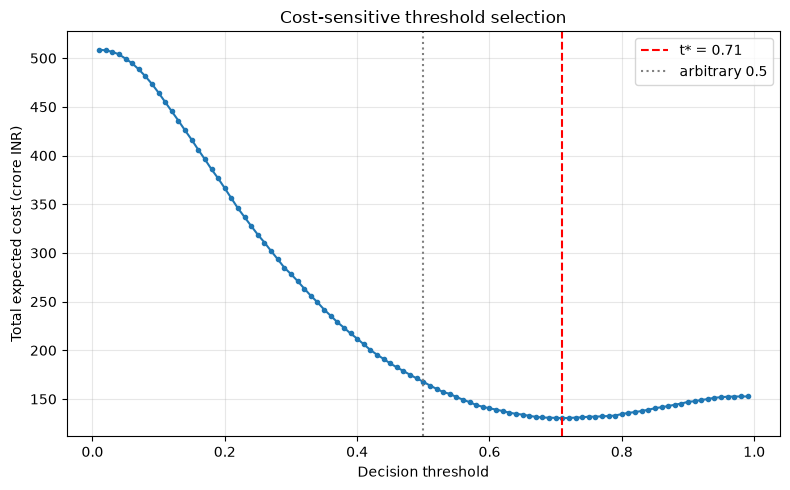

Saved to ../figures/cost_sensitive_threshold.png


In [21]:
# Cell 22: Plot total expected cost vs threshold
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_sweep['threshold'], cost_sweep['total_cost'] / 1e7, marker='.')
ax.axvline(t_star, color='red', linestyle='--', label=f't* = {t_star}')
ax.axvline(0.5, color='gray', linestyle=':', label='arbitrary 0.5')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Total expected cost (crore INR)')
ax.set_title('Cost-sensitive threshold selection')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/cost_sensitive_threshold.png', dpi=150)
plt.show()
print("Saved to ../figures/cost_sensitive_threshold.png")

In [22]:
# Cell 23: Operating-point comparison, 0.5 vs t*
row_05 = cost_sweep[cost_sweep['threshold'] == 0.5].iloc[0]
row_ts = cost_sweep[cost_sweep['threshold'] == t_star].iloc[0]
cost_reduction_pct = (row_05['total_cost'] - row_ts['total_cost']) / row_05['total_cost'] * 100

print(f"{'':20s} {'threshold=0.5':>18s} {'threshold=t*':>18s}")
print(f"{'Total cost (INR)':20s} {row_05['total_cost']:>18,.0f} {row_ts['total_cost']:>18,.0f}")
print(f"{'Approval rate':20s} {row_05['approval_rate']:>18.4%} {row_ts['approval_rate']:>18.4%}")
print(f"{'Default rate (approved)':20s} {row_05['approved_default_rate']:>18.4%} {row_ts['approved_default_rate']:>18.4%}")
print()
print(f"Cost reduction at t* vs 0.5: {cost_reduction_pct:.1f}%")

                          threshold=0.5       threshold=t*
Total cost (INR)          1,677,194,226      1,304,171,764
Approval rate                  71.5159%           90.2798%
Default rate (approved)            3.5423%            5.5274%

Cost reduction at t* vs 0.5: 22.2%


### Does the calibrated threshold change the fairness conclusions?

Re-running the gender and region-tier fairness metrics at `t*` instead of 0.5 -- same "diagnose before trust" discipline as every attribute above: per-group TPR/FPR checked before trusting the headline DPD/EOD change.

In [23]:
# Cell 24: Gender and region-tier fairness at t* vs 0.5
gender_at_tstar = compute_fairness_metrics(
    y_test, y_proba, X_test['CODE_GENDER_F'], threshold=t_star, label='Gender @ t*'
)
region_at_tstar = compute_fairness_metrics(
    y_test, y_proba, X_test['REGION_RATING_CLIENT'], threshold=t_star, label='Region tier @ t*'
)
print()
print(f"Gender DPD: {gender_fairness['demographic_parity_difference']:.4f} (@0.5) -> "
      f"{gender_at_tstar['demographic_parity_difference']:.4f} (@t*)")
print(f"Gender EOD: {gender_fairness['equalized_odds_difference']:.4f} (@0.5) -> "
      f"{gender_at_tstar['equalized_odds_difference']:.4f} (@t*)")
print(f"Region DPD: {region_fairness['demographic_parity_difference']:.4f} (@0.5) -> "
      f"{region_at_tstar['demographic_parity_difference']:.4f} (@t*)")
print(f"Region EOD: {region_fairness['equalized_odds_difference']:.4f} (@0.5) -> "
      f"{region_at_tstar['equalized_odds_difference']:.4f} (@t*)")

Gender @ t* -> demographic parity diff: 0.0657 | equalized odds diff: 0.1209
    group=False: selection_rate=0.1404 | AUC=0.7904
    group=True: selection_rate=0.0747 | AUC=0.7851


Region tier @ t* -> demographic parity diff: 0.1369 | equalized odds diff: 0.3283
    group=1: selection_rate=0.0317 | AUC=0.7992
    group=2: selection_rate=0.0914 | AUC=0.7847
    group=3: selection_rate=0.1686 | AUC=0.7891

Gender DPD: 0.1385 (@0.5) -> 0.0657 (@t*)
Gender EOD: 0.1316 (@0.5) -> 0.1209 (@t*)
Region DPD: 0.2769 (@0.5) -> 0.1369 (@t*)
Region EOD: 0.2519 (@0.5) -> 0.3283 (@t*)


In [24]:
# Cell 25: Diagnose the region-tier EOD change -- per-group TPR/FPR at 0.5 vs t*
for t, tag in [(0.5, '0.5'), (t_star, 't*')]:
    y_pred_t = (y_proba >= t).astype(int)
    df_diag = pd.DataFrame({'y_true': y_test.to_numpy(), 'y_pred': y_pred_t,
                            'region': X_test['REGION_RATING_CLIENT'].to_numpy()})
    print(f'--- threshold={tag} ---')
    for grp, sub in df_diag.groupby('region'):
        pos = sub[sub.y_true == 1]; neg = sub[sub.y_true == 0]
        tpr = (pos.y_pred == 1).mean() if len(pos) else float('nan')
        fpr = (neg.y_pred == 1).mean() if len(neg) else float('nan')
        print(f'  region={grp}: n_pos={len(pos)} n_neg={len(neg)} TPR={tpr:.4f} FPR={fpr:.4f}')

--- threshold=0.5 ---
  region=1: n_pos=303 n_neg=6079 TPR=0.5479 FPR=0.1235
  region=2: n_pos=3594 n_neg=41946 TPR=0.6697 FPR=0.2423
  region=3: n_pos=1068 n_neg=8511 TPR=0.7809 FPR=0.3754
--- threshold=t* ---
  region=1: n_pos=303 n_neg=6079 TPR=0.1782 FPR=0.0243
  region=2: n_pos=3594 n_neg=41946 TPR=0.3620 FPR=0.0682
  region=3: n_pos=1068 n_neg=8511 TPR=0.5066 FPR=0.1262


**Finding**: the cost-calibrated threshold (`t*`) is not a uniform fairness improvement. Diagnosed with the same per-group TPR/FPR discipline used throughout this notebook (all three region tiers have solid sample sizes -- n_pos 303 to 3,594 -- so this is not a small-sample artifact):

- **Demographic parity improves** for both gender and region tier at `t*` (fewer people flagged high-risk overall shrinks the gap in flagging *rates* between groups).
- **Gender equalized odds** improves slightly at `t*`.
- **Region-tier equalized odds gets worse** at `t*` (0.2519 -> 0.3283). At 0.5 the binding gap was FPR (Tier 3 vs Tier 1); at the higher `t*` threshold, TPR drops far more steeply for Tier 1 (0.548 -> 0.178) than for Tier 3 (0.781 -> 0.507), so the TPR gap becomes the new binding, larger constraint -- raising the threshold to cut costs disproportionately stops catching Tier 1 defaulters relative to Tier 3 ones.

Reported as-is: **the cost-optimal operating point and the fairest operating point are not the same threshold** -- a real trade-off for the thesis discussion, not smoothed over the way every other pass in this notebook was clean.